In [55]:
import numpy as np
from scipy.interpolate import interp1d
from reader import *
import matplotlib.pyplot as plt

In [56]:
geo = Reader("tests/cone.geo", cascade=False)
geo.collate_pt(0)

(1, -0.3364470899105072, -0.0016453739954158664, -0.10011979192495346)

In [57]:
pts = []
for i in range(256, 512):
    pts.append(np.array(geo.collate_2d(i)))
points = np.asarray(pts)
points

array([[-3.36441278e-01, -1.64534175e-03],
       [-3.36456507e-01,  2.89575683e-17],
       [-3.36434782e-01, -3.29073193e-03],
       [-3.36398095e-01, -4.94659273e-03],
       [-3.36366624e-01, -6.60255132e-03],
       [-3.36306274e-01, -8.27939808e-03],
       [-3.36249232e-01, -9.95636079e-03],
       [-3.36163431e-01, -1.16645545e-02],
       [-3.36080611e-01, -1.33728953e-02],
       [-3.35970044e-01, -1.51228374e-02],
       [-3.35858732e-01, -1.68727040e-02],
       [-3.35720628e-01, -1.86744425e-02],
       [-3.35575253e-01, -2.04755813e-02],
       [-3.35401475e-01, -2.23384090e-02],
       [-3.35220069e-01, -2.42005326e-02],
       [-3.35006505e-01, -2.61337403e-02],
       [-3.34789217e-01, -2.80665439e-02],
       [-3.34535927e-01, -3.00796535e-02],
       [-3.34275931e-01, -3.20918597e-02],
       [-3.33974034e-01, -3.41928750e-02],
       [-3.33661646e-01, -3.62923704e-02],
       [-3.33304912e-01, -3.84891853e-02],
       [-3.32936823e-01, -4.06841189e-02],
       [-3.

In [58]:
def unique_z(arr, start, finish):
    unique = []
    unique.append(arr[0][2])
    for i in range(start, finish):
        if 2 <= len(unique):
            break
        if arr[i][2] in unique:
            continue
        else:
            unique.append(arr[i][2])
    return np.array(unique)
print(np.mean(unique_z(pts, 0, 256)))

IndexError: index 2 is out of bounds for axis 0 with size 2

True

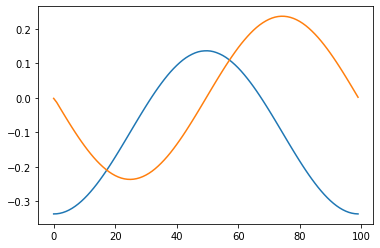

In [67]:
# Linear length along the line:
distance = np.cumsum( np.sqrt(np.sum( np.diff(points, axis=0)**2, axis=1 )) )
distance = np.insert(distance, 0, 0)/distance[-1]

interpolator = interp1d(distance, points, kind='cubic', axis=0)
interpolated_new = interpolator(np.linspace(0, 1, 100))
plt.plot(interpolated_new)
def check(point_x, point_y, interp):
    if point_y == interp(point_x).all():
        return True
    else:
        return False
check(0, 1, interpolator)

In [37]:
# Interpolation for different methods:
interpolations_methods = ['slinear', 'quadratic', 'cubic']
alpha = np.linspace(0, 1, 75)

interpolated_points = {}
for method in interpolations_methods:
    interpolator = interp1d(distance, points, kind=method, axis=0)
    interpolated_points[method] = interpolator(alpha)

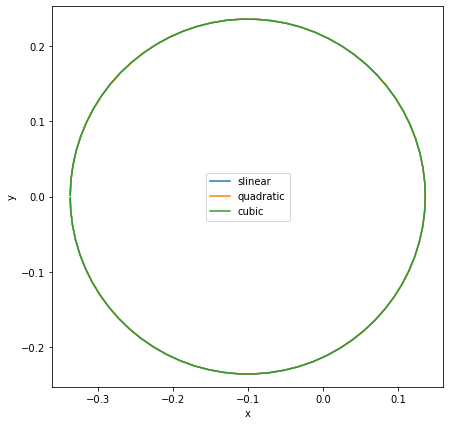

In [35]:
# Graph:
plt.figure(figsize=(7,7))
for method_name, curve in interpolated_points.items():
    plt.plot(*curve.T, '-', label=method_name);


#plt.plot(*points.T, 'ok', label='original points');
plt.axis('equal'); plt.legend(); plt.xlabel('x'); plt.ylabel('y');